# Star-domain vs star-domain interactions

The existing exclusion term in `radially_convex` works **circle-by-circle**: the boundary of set $A$ is pushed back from any circle belonging to set $B$. ...

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import SVG

from vizopt.animation import SnapshotCallback, snapshots_to_animated_svg
from vizopt.base import OptimConfig
from vizopt.components import stars
from vizopt.components.stars import _svg_configuration_star_only
from vizopt.examples.sets import graph_to_optimizer_inputs, make_british_islands_graph
from vizopt.templates import star_vs_star
from vizopt.templates.star_vs_star import StarDomainOptimizer, StarVsStarOptimizer

## Random Fourier star domains

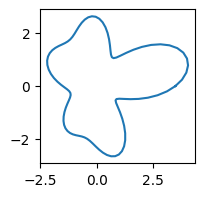

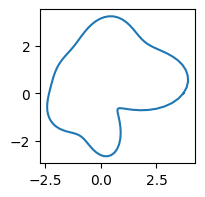

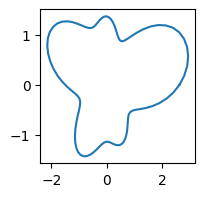

In [2]:
def get_random_radii(thetas, seed, r_constant=1, r_constant_factor=0.5):
    rng = np.random.default_rng(seed)
    k = 5
    random_fourier_coeffs = rng.random((k, 2))
    

    mult_thetas = thetas.reshape(-1, 1) * np.arange(1, k + 1)
    logradii = (np.cos(mult_thetas) * random_fourier_coeffs[:, 0]).sum(axis=1) + (
        np.sin(mult_thetas) * random_fourier_coeffs[:, 1]
    ).sum(axis=1)

    radii = logradii + 1 - min(0, min(logradii))
    radii = r_constant_factor * r_constant + (1 - r_constant_factor) * radii
    return radii

thetas = np.linspace(0, 2 * np.pi, 100)
for seed in range(3):
    
    radii = get_random_radii(thetas, seed)

    x = radii * np.cos(thetas)
    y = radii * np.sin(thetas)

    _, ax = plt.subplots(figsize=(2, 2))
    ax.plot(x, y)


### Example: two star domains

(np.float64(-2.806364907606493),
 np.float64(10.528912831138273),
 np.float64(-3.2856150810811897),
 np.float64(10.573712329140143))

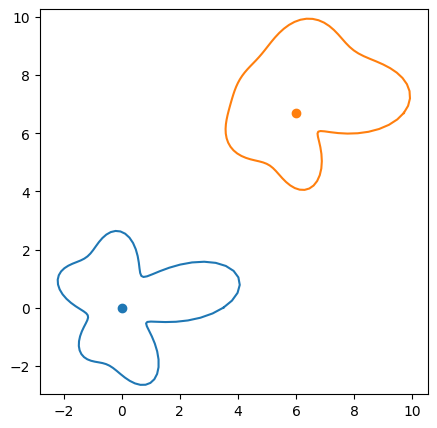

In [3]:
radii_a = get_random_radii(thetas, 0)
radii_b = get_random_radii(thetas, 1)

center_a = (0, 0)
center_b = (6, 6.7)

x_a = center_a[0] + radii_a * np.cos(thetas)
y_a = center_a[1] + radii_a * np.sin(thetas)

x_b = center_b[0] + radii_b * np.cos(thetas)
y_b = center_b[1] + radii_b * np.sin(thetas)

_, ax = plt.subplots(figsize=(5, 5))
ax.scatter(center_a[0], center_a[1])
ax.plot(x_a, y_a)

ax.scatter(center_b[0], center_b[1])
ax.plot(x_b, y_b)
plt.axis("equal")

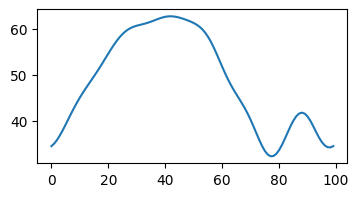

In [4]:
tan_theta_a_by_theta_b = (y_b - center_a[1]) / (x_b - center_a[0])
theta_a_by_theta_b = np.arctan(tan_theta_a_by_theta_b)
_, ax = plt.subplots(figsize=(4, 2))
ax.plot(180/np.pi * theta_a_by_theta_b)

There is a collision if and only if min(b_from_center_a - radii_a_by_theta_b) < 0

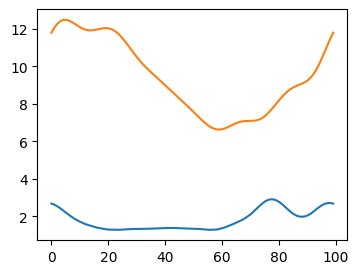

In [5]:
_, ax = plt.subplots(figsize=(4, 3))
radii_a_by_theta_b = np.interp(theta_a_by_theta_b, thetas, radii_a)
plt.plot(radii_a_by_theta_b)

b_from_center_a = np.linalg.norm(np.array([x_b - center_a[0], y_b - center_a[1]]).T, axis=1)

plt.plot(b_from_center_a)

## Star-vs-star exclusion term

The current `_multi_term_exclusion` is **star vs circle**: for each ray of set $A$, it checks whether the boundary extends past the near face of any non-member circle. This means set $A$ can still enter the *interior* of set $B$ in gaps between $B$'s circles.

The **star-vs-star** approach instead asks: for each boundary point $p_k$ of set $A$, is $p_k$ inside the star domain of set $B$? This is computed by:

1. Finding the vector $d = p_k - c_B$ (direction and distance from $B$'s center)
2. Interpolating $B$'s radius at the angle of $d$: $R_B(\alpha)$
3. Penalising when $\|d\| < R_B(\alpha)$, i.e. $p_k$ is inside $B$

This is a strictly geometric check against the *actual optimised boundary* of $B$, not the underlying circles.

## Collision demo: exclusion loss as one set enters another

Set A (blue, fixed at the origin) stays stationary throughout.
Set B (orange) slides from far right toward the centre until it deeply overlaps A.

The loss curve below shows `_multi_term_star_exclusion` (unweighted):
it is **exactly zero** while the two boundaries do not touch, and rises smoothly once
B's boundary points enter A's star interior — and A's boundary points enter B's.

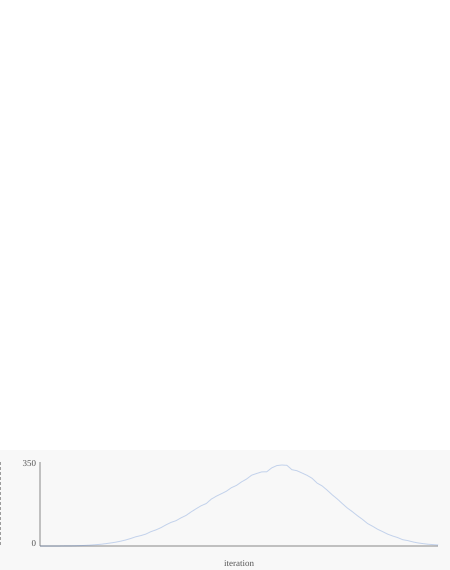

In [6]:
from vizopt.base import OptimizationProblem

K_DEMO = 64
angles_demo = np.linspace(0, 2 * np.pi, K_DEMO, endpoint=False).astype(np.float32)

# Two random star shapes, each normalised so its maximum radius is 1.5
r_constant_factor = 0.5
radii_a = get_random_radii(angles_demo, r_constant_factor=r_constant_factor, seed=0).astype(np.float32)
radii_b = get_random_radii(angles_demo, r_constant_factor=r_constant_factor, seed=1).astype(np.float32)
radii_a = (radii_a / radii_a.max() * 2.5)
radii_b = (radii_b / radii_b.max() * 2.5)

# A fixed at origin; B travels from x=4 to x=-3 along the x-axis
center_a = np.array([0.0, 0.0], dtype=np.float32)
start_b  = np.array([4.0, 0.0], dtype=np.float32)
end_b    = np.array([-3.0, 0.0], dtype=np.float32)

n_steps = 80
t_vals = np.linspace(0.0, 1.0, n_steps, dtype=np.float32)

exclusion_mask = np.array([[False, True], [True, False]], dtype=bool)
input_params_demo = {
    "angles": angles_demo,
    "exclusion_mask": exclusion_mask,
    "exclusion_interior_fracs": [0.25, 0.5, 0.75],
}

snapshots_demo = []
history_demo   = []

for i, t in enumerate(t_vals):
    center_b = start_b + t * (end_b - start_b)
    centers  = np.stack([center_a, center_b], axis=0)   # (2, 2)
    radii    = np.stack([radii_a,  radii_b],  axis=0)   # (2, K)
    optim_vars = {"centers": centers, "radii": radii}
    loss = float(star_vs_star._multi_term_star_exclusion(optim_vars, input_params_demo))
    snapshots_demo.append((i, {"centers": centers.copy(), "radii": radii.copy()}))
    history_demo.append({"iteration": i, "total": loss})

# Tiny floor so the y-axis never spans a degenerate range
for h in history_demo:
    h["total"] = max(h["total"], 1e-9)

problem_demo = OptimizationProblem(
    input_parameters={"angles": angles_demo},
    terms=[],
    initialize=lambda input_parameters, seed: {},
    svg_configuration=_svg_configuration_star_only,
)

svg_collision = snapshots_to_animated_svg(
    problem_demo, snapshots_demo, fps=2, size=450,
    history=history_demo, log_scale=False,
)
SVG(data=svg_collision)

In [7]:
# Maybe need to be a bit more aggressive for small collisions rather than linear?

## Demo: star-vs-star vs star-vs-circle exclusion

Two interleaved groups of circles where the star boundaries would naturally overlap.
The **star-vs-circle** approach (left) can let boundaries slip into the gap between
circles of the opposing set; **star-vs-star** (right) enforces separation against the
full optimised boundary.

In [8]:
# Two groups of circles that sit close together so their envelopes want to overlap.
# Group A (indices 0-2): small cluster on the left
# Group B (indices 3-5): small cluster on the right, partially interleaved
circles = np.array([
    # Group A
    [-0.3,  1.3, 0.4],
    [-0.6, -0.3, 0.4],
    [0.5, -0.4, 0.35],
    # Group B
    [2.0,  0.5, 0.4],
    [2.7, -0.3, 0.4],
    [0.5, 0.7, 0.35],
], dtype=np.float32)

sets = [{0, 1, 2}, {3, 4, 5}]

config = OptimConfig(n_iters=3000, learning_rate=5e-3)

# --- star-vs-star (new) ---
svs = StarVsStarOptimizer(
    circles, sets, representation=stars.Discrete(k_angles=64), weight_exclusion=20.0, offsets=0.15,
)
svs.optimize(config)
results_svs = svs.sets_
history_svs = svs.result_.history
problem_svs = svs.problem_

Iteration 0: loss = 125.009521484375
Iteration 100: loss = 30.08510971069336
Iteration 200: loss = 25.865102767944336
Iteration 300: loss = 25.388538360595703
Iteration 400: loss = 25.156644821166992
Iteration 500: loss = 25.18766212463379
Iteration 600: loss = 25.149921417236328
Iteration 700: loss = 25.171409606933594
Iteration 800: loss = 25.156179428100586
Iteration 900: loss = 25.203445434570312
Iteration 1000: loss = 25.157699584960938
Iteration 1100: loss = 25.16604232788086
Iteration 1200: loss = 25.182249069213867
Iteration 1300: loss = 25.154064178466797
Iteration 1400: loss = 25.17272186279297
Iteration 1500: loss = 25.143518447875977
Iteration 1600: loss = 25.136676788330078
Iteration 1700: loss = 25.17230224609375
Iteration 1800: loss = 25.143529891967773
Iteration 1900: loss = 25.12982940673828
Iteration 2000: loss = 25.151195526123047
Iteration 2100: loss = 25.15741539001465
Iteration 2200: loss = 25.145307540893555
Iteration 2300: loss = 25.14324951171875
Iteration 2400

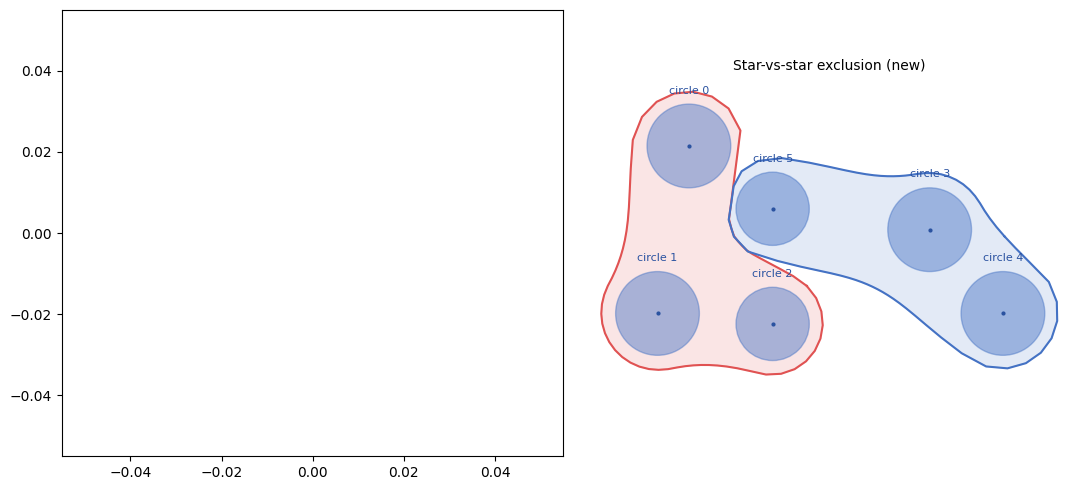

In [9]:
from vizopt.utils import _SVG_SET_COLORS

def plot_results(ax, results, circles, title):
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.axis("off")

    # Draw circles
    for i_circle, (cx, cy, r) in enumerate(circles):
        patch = plt.Circle((cx, cy), r, color="#4472c4", alpha=0.45, zorder=2)
        ax.add_patch(patch)
        ax.plot(cx, cy, "o", color="#2a52a0", ms=2, zorder=3)
        ax.text(cx, cy + r + 0.1, f"circle {i_circle}", ha="center", fontsize=8, color="#2a52a0")

    # Draw star boundaries
    for s, res in enumerate(results):
        color = _SVG_SET_COLORS[s % len(_SVG_SET_COLORS)]
        angs = res["angles"]
        radii = res["radii"]
        cx, cy = res["center"]
        bx = cx + radii * np.cos(angs)
        by = cy + radii * np.sin(angs)
        # close the polygon
        bx = np.append(bx, bx[0])
        by = np.append(by, by[0])
        ax.fill(bx, by, color=color, alpha=0.15, zorder=1)
        ax.plot(bx, by, color=color, lw=1.5, zorder=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_results(axes[1], results_svs, circles, "Star-vs-star exclusion (new)")

for ax in axes:
    ax.autoscale_view()

plt.tight_layout()
plt.show()

Iteration 0: loss = 435.3140563964844
Iteration 100: loss = 44.52591323852539
Iteration 200: loss = 28.337175369262695
Iteration 300: loss = 25.714462280273438
Iteration 400: loss = 25.075428009033203
Iteration 500: loss = 24.917011260986328
Iteration 600: loss = 24.893024444580078
Iteration 700: loss = 24.879409790039062
Iteration 800: loss = 24.84415626525879
Iteration 900: loss = 25.49770164489746
Iteration 1000: loss = 24.972278594970703
Iteration 1100: loss = 24.83542251586914
Iteration 1200: loss = 24.819534301757812
Iteration 1300: loss = 25.072093963623047
Iteration 1400: loss = 24.905414581298828
Iteration 1500: loss = 24.813621520996094
Iteration 1600: loss = 24.9312744140625
Iteration 1700: loss = 24.81268310546875
Iteration 1800: loss = 24.800424575805664
Iteration 1900: loss = 24.80512046813965
Iteration 2000: loss = 25.793964385986328
Iteration 2100: loss = 24.81869125366211
Iteration 2200: loss = 25.7738094329834
Iteration 2300: loss = 24.834354400634766
Iteration 2400: 

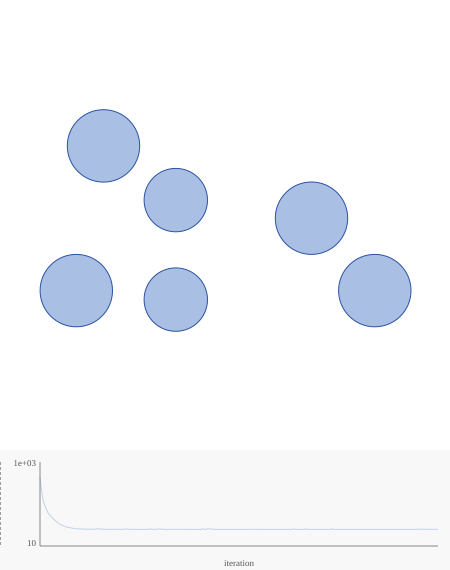

In [10]:
# Animated SVG of the star-vs-star run
cb = SnapshotCallback(every=50)
svs_anim = StarVsStarOptimizer(
    circles, sets, representation=stars.Discrete(k_angles=256), weight_exclusion=20.0, offsets=0.15,
)
svs_anim.optimize(OptimConfig(n_iters=3000, learning_rate=5e-3), callback=cb)
svg = svs_anim.animate_svg(cb, fps=12, size=450, log_scale=True)
SVG(data=svg)

## Demo: pure star domains with area targets

Set 0 (target area 1), set 1 (target area 2), set 2 (no target — shrinks to fit).
Constraints: set 0 ⊂‚ set 2, set 1 ⊂‚ set 2. Sets 0 and 1 are mutually exclusive.

In [11]:
# Initial centers: sets 0 and 1 side-by-side, set 2 centred between them.
# The optimiser will adjust centers together with the radii.
r0_init = star_vs_star._radius_from_target_area(1.0, 64)
r1_init = star_vs_star._radius_from_target_area(2.0, 64)

initial_centers_pure = np.array([
    [-r0_init,  0.0],   # set 0 — left
    [ r1_init,  0.0],   # set 1 — right
    [     0.0,  0.0],   # set 2 — outer container, centred
], dtype=np.float32)

cb_pure = SnapshotCallback(every=30)
pure = StarDomainOptimizer(
    n_sets=3,
    initial_centers=initial_centers_pure,
    representation=stars.Discrete(k_angles=64),
    target_areas=[1.0, 2.0, None],
    initial_radius=max(r0_init, r1_init) * 2.5,
    weight_target_area=20.0,
    weight_area=1.0,
    weight_perimeter=0.5,
    weight_exclusion=15.0,
    weight_enclosure=25.0,
    weight_smoothness=0.5,
    enclosures=[(0, 2), (1, 2)],
)
pure.optimize(OptimConfig(n_iters=1000, learning_rate=3e-3), callback=cb_pure)
results_pure = pure.sets_
history_pure = pure.result_.history
problem_pure = pure.problem_

# Report achieved areas
K = 64
dt = 2 * np.pi / K
for s, res in enumerate(results_pure):
    r = res["radii"]
    area = 0.5 * np.sin(dt) * np.sum(r * np.roll(r, -1))
    target = [1.0, 2.0, "—"][s]
    print(f"Set {s}: area = {area:.4f}  (target: {target})")

Iteration 0: loss = 27.341262817382812
Iteration 100: loss = 21.671871185302734
Iteration 200: loss = 18.292888641357422
Iteration 300: loss = 15.98291015625
Iteration 400: loss = 14.826363563537598
Iteration 500: loss = 14.651798248291016
Iteration 600: loss = 14.615422248840332
Iteration 700: loss = 14.600643157958984
Iteration 800: loss = 14.593811988830566
Iteration 900: loss = 14.590386390686035
Set 0: area = 0.9063  (target: 1.0)
Set 1: area = 1.9176  (target: 2.0)
Set 2: area = 3.5840  (target: —)


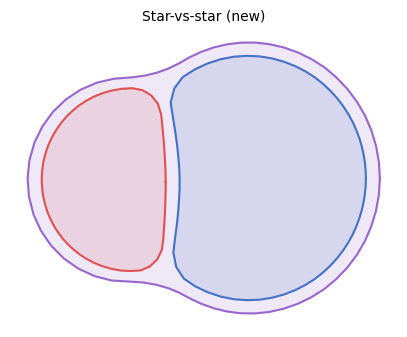

In [12]:
_, ax = plt.subplots(figsize=(5, 5))
plot_results(ax, results_pure, [], "Star-vs-star (new)")

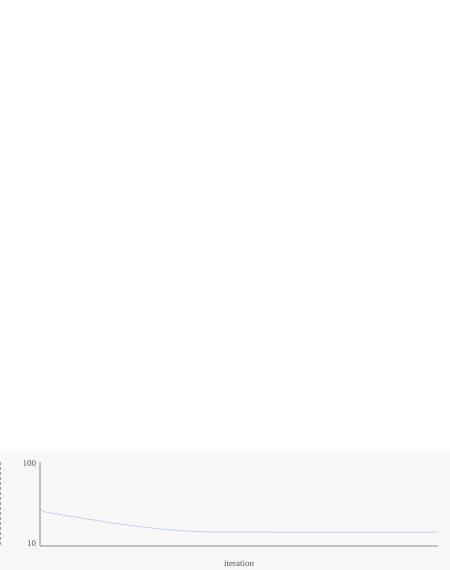

In [13]:
svg_pure = pure.animate_svg(cb_pure, fps=5, size=450, log_scale=True)
SVG(data=svg_pure)

Iteration 0: loss = 8027.3203125
Iteration 100: loss = 44.38837432861328
Iteration 200: loss = 36.437461853027344
Iteration 300: loss = 33.765804290771484
Iteration 400: loss = 32.42320251464844
Iteration 500: loss = 31.58029556274414
Iteration 600: loss = 30.934722900390625
Iteration 700: loss = 30.396202087402344
Iteration 800: loss = 29.93076515197754
Iteration 900: loss = 29.517467498779297
Iteration 1000: loss = 29.14908218383789
Iteration 1100: loss = 28.826045989990234
Iteration 1200: loss = 28.549781799316406
Iteration 1300: loss = 28.315277099609375
Iteration 1400: loss = 28.116323471069336
Iteration 1500: loss = 27.94953727722168
Iteration 1600: loss = 27.811622619628906
Iteration 1700: loss = 27.697593688964844
Iteration 1800: loss = 27.602235794067383
Iteration 1900: loss = 27.51980209350586
Set 0: area = 0.4431  (target: 1.0)
Set 1: area = 0.9698  (target: 2.0)
Set 2: area = 2.5671  (target: —)
Set 3: area = 0.4615  (target: 1.0)
Set 4: area = 1.7292  (target: —)


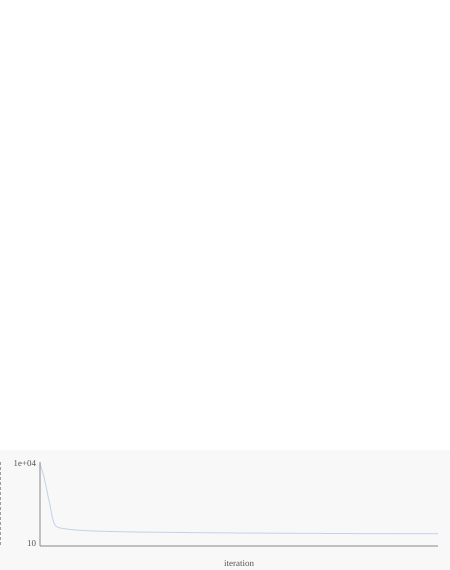

In [14]:
r0_init = star_vs_star._radius_from_target_area(1.0, 64)
r1_init = star_vs_star._radius_from_target_area(2.0, 64)

initial_centers_pure = np.array([
    [-r0_init/2,  0.0],
    [ r1_init/2,  0.0],
    [     0.0,  0.0],
    [     0.0,  r0_init],
    [    -r0_init,  r0_init],
], dtype=np.float32)

cb_pure = SnapshotCallback(every=30)
representation = stars.BSpline(n_ctrl_pts=16)

pure5 = StarDomainOptimizer(
    n_sets=5,
    initial_centers=initial_centers_pure,
    representation=representation,
    target_areas=[1.0, 2.0, None, 1.0, None],
    initial_radius=max(r0_init, r1_init) * 2.5,
    weight_target_area=20.0,
    weight_area=1.0,
    weight_perimeter=0.5,
    weight_exclusion=15.0,
    weight_enclosure=25.0,
    weight_smoothness=2.,
    enclosures=[(0, 2), (1, 2), (0, 4), (3, 4)],
    exclusion_offset=0.2,
)
pure5.optimize(OptimConfig(n_iters=2000, learning_rate=1e-2), callback=cb_pure)
results_pure = pure5.sets_

# Report achieved areas
K = 128
dt = 2 * np.pi / K
for s, res in enumerate(results_pure):
    r = res["radii"]
    area = 0.5 * np.sin(dt) * np.sum(r * np.roll(r, -1))
    target = [1.0, 2.0, "—", 1.0,  "—"][s]
    print(f"Set {s}: area = {area:.4f}  (target: {target})")

svg_pure = pure5.animate_svg(cb_pure, fps=15, size=450, log_scale=True)
SVG(data=svg_pure)

## Euler diagram: the British Islands


In [15]:
G_british = make_british_islands_graph(include_british_isles=True)
set_names, idx, enclosures, target_areas, initial_centers = graph_to_optimizer_inputs(G_british)
S = len(set_names)

cb_bi = SnapshotCallback(every=100)

representation = stars.BSpline(n_ctrl_pts=16)

bi = StarDomainOptimizer(
    n_sets=S,
    initial_centers=initial_centers,
    representation=representation,
    target_areas=target_areas,
    initial_radius=5.0,
    weight_target_area=20.0,
    weight_area=0.3,
    weight_perimeter=0.3,
    weight_exclusion=15.0,
    weight_enclosure=30.0,
    weight_smoothness=2.0,
    enclosures=enclosures,
    enclosure_offset=0.2,
    exclusion_offset=0.2,
    exclusion_interior_fracs=[0.25, 0.5, 0.75],
)
bi.optimize(OptimConfig(n_iters=12000, learning_rate=5e-3), callback=cb_bi)
results_bi = bi.sets_
history_bi = bi.result_.history
problem_bi = bi.problem_
print(f"Captured {len(cb_bi.snapshots)} snapshots")

Iteration 0: loss = 505250.5625
Iteration 100: loss = 309271.15625
Iteration 200: loss = 188505.703125
Iteration 300: loss = 118746.265625
Iteration 400: loss = 80232.84375
Iteration 500: loss = 58590.6015625
Iteration 600: loss = 45152.39453125
Iteration 700: loss = 35696.640625
Iteration 800: loss = 28472.79296875
Iteration 900: loss = 22761.1875
Iteration 1000: loss = 18203.5078125
Iteration 1100: loss = 14566.2890625
Iteration 1200: loss = 11672.2529296875
Iteration 1300: loss = 9376.4921875
Iteration 1400: loss = 7556.88671875
Iteration 1500: loss = 6110.42529296875
Iteration 1600: loss = 4959.08544921875
Iteration 1700: loss = 4041.239501953125
Iteration 1800: loss = 3308.191650390625
Iteration 1900: loss = 2721.343017578125
Iteration 2000: loss = 2252.8486328125
Iteration 2100: loss = 1876.625244140625
Iteration 2200: loss = 1572.3858642578125
Iteration 2300: loss = 1325.591552734375
Iteration 2400: loss = 1125.27490234375
Iteration 2500: loss = 962.0328369140625
Iteration 2600:

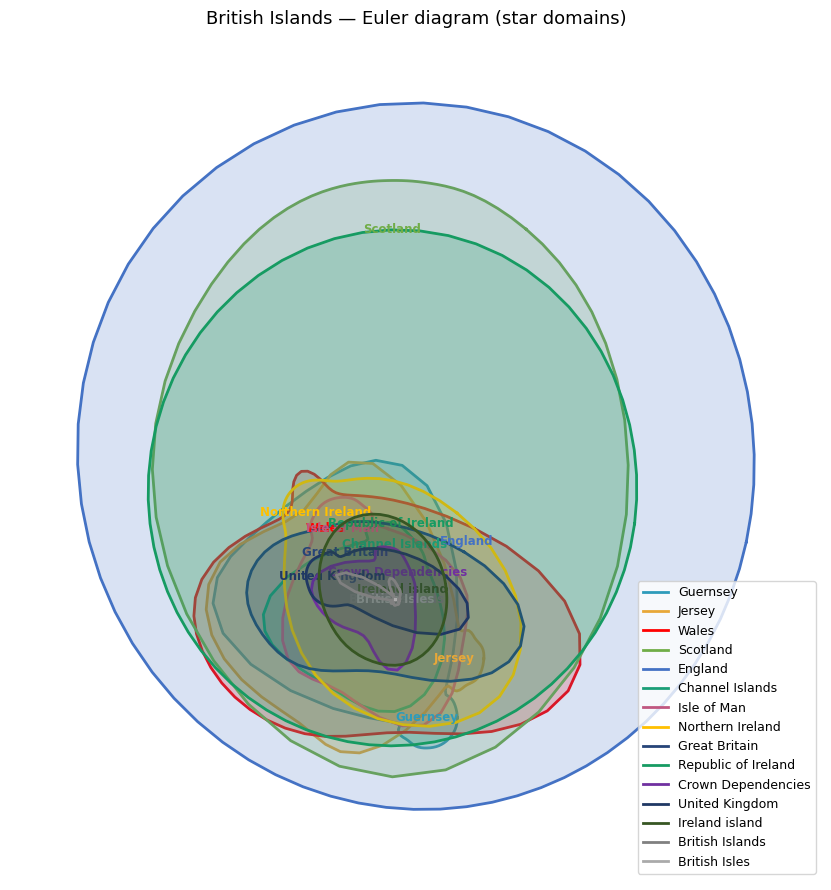

In [16]:


set_colors = [G_british.nodes[name]["color"] for name in set_names]
topo = list(nx.topological_sort(G_british))  # children before parents
z_order = [set_names.index(n) for n in reversed(topo)]  # outermost (parents) drawn first

fig, ax = plt.subplots(figsize=(9, 9))

for s in z_order:
    result = results_bi[s]
    name = set_names[s]
    color = set_colors[s]
    cx, cy = result["center"]
    radii = result["radii"]
    angles = result["angles"]
    bx = np.append(cx + radii * np.cos(angles), cx + radii[0] * np.cos(angles[0]))
    by = np.append(cy + radii * np.sin(angles), cy + radii[0] * np.sin(angles[0]))
    ax.fill(bx, by, alpha=0.20, color=color, zorder=z_order.index(s))
    ax.plot(bx, by, color=color, linewidth=2, label=name, zorder=z_order.index(s) + 0.5)
    ax.text(cx, cy, name, ha="center", va="center", fontsize=8.5,
            color=color, fontweight="bold", zorder=10)

ax.set_aspect("equal")
ax.autoscale_view()
ax.margins(0.1)
ax.axis("off")
ax.set_title("British Islands — Euler diagram (star domains)", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()

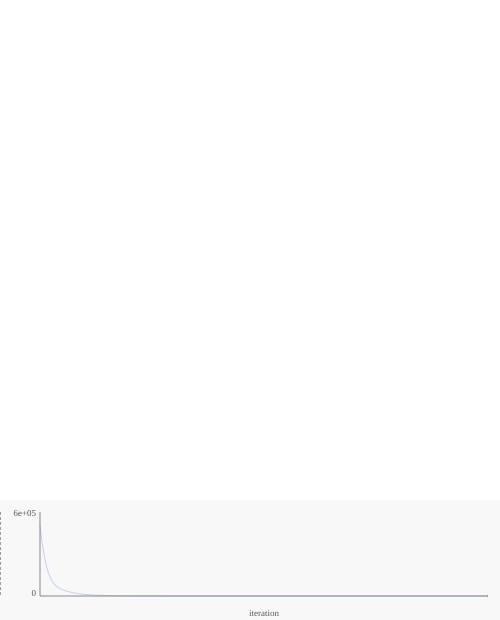

In [17]:
svg_bi = bi.animate_svg(cb_bi, fps=20, size=500)
SVG(data=svg_bi)